# LAB 01 — Khám phá và chuẩn bị dữ liệu Student Performance Factors

**DNU Learning Analytics Lab**

- **Họ tên:** Nghiêm Minh Phúc
- **MSSV:** 1871020457
- **Lớp:** CNTT 18-11

> **Câu hỏi trung tâm:** Dataset này có đủ hiểu, đủ sạch và đủ phù hợp để bắt đầu modeling chưa?


## Environment checkpoint

Chạy cell dưới đây. Nếu không có lỗi import, môi trường đã sẵn sàng cho bài lab.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment ready!")
print("pandas:", pd.__version__)


Environment ready!
pandas: 3.0.3


# Mission 1 — Understand the dataset

## Nhiệm vụ

1. Đọc file `data/StudentPerformanceFactors.csv`.
2. Quan sát các dòng đầu tiên.
3. Kiểm tra kích thước dataset.
4. Kiểm tra kiểu dữ liệu và non-null count.
5. Trả lời bằng Markdown:
   - Một row đại diện cho đối tượng nào?
   - Dataset có bao nhiêu samples và variables?
   - Target gốc là cột nào?
   - Nếu dự đoán trực tiếp target này, đây là regression hay classification?


In [2]:
# Đọc dữ liệu bằng đường dẫn tương đối
df = pd.read_csv("data/StudentPerformanceFactors.csv")

# Khám phá sơ bộ
display(df.head())
print("Shape:", df.shape)
df.info()


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


Shape: (6607, 20)
<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  P

In [3]:
# Xem thêm một vài dòng cuối và thống kê mô tả
display(df.tail())
display(df.describe())


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68
6606,15,67,Medium,Low,Yes,9,94,Medium,Yes,0,Medium,Medium,Public,Positive,4,No,Postgraduate,Near,Male,64


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


### Kết luận Mission 1

- Một row đại diện cho: **một sinh viên (student) cùng các yếu tố ảnh hưởng đến kết quả học tập của sinh viên đó**
- Số samples: **6607**
- Số variables: **20** (19 features + 1 target)
- Target gốc: **`Exam_Score`** — điểm thi cuối kỳ của sinh viên
- Dạng bài toán nếu dự đoán trực tiếp target: **Regression** (hồi quy)

**Giải thích ngắn:**  
Dataset chứa 6607 bản ghi, mỗi bản ghi mô tả một sinh viên với 19 đặc trưng (features) bao gồm thông tin về thời gian học, tỷ lệ đi học, sự tham gia của phụ huynh, mức thu nhập gia đình, v.v. Biến mục tiêu `Exam_Score` là biến liên tục (số nguyên từ 55 đến 101), do đó nếu dự đoán trực tiếp giá trị này, đây là bài toán **regression**. Trong 20 cột, có 7 cột numeric (int64) và 13 cột categorical (object/string).


# Mission 2 — Build a data dictionary

Pandas dtype cho biết cách máy đang lưu dữ liệu, nhưng không phải lúc nào cũng phản ánh đầy đủ **ý nghĩa dữ liệu**.

Hãy phân loại các cột thành:

- numerical;
- categorical;
- ordinal categorical;
- target.

Tạo một bảng Data Dictionary có tối thiểu các cột:

| Variable | Ý nghĩa | Pandas dtype | Semantic type | Vai trò dự kiến |
|---|---|---|---|---|


In [4]:
# Gợi ý: xác định nhanh nhóm cột theo dtype
numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric columns:")
print(numeric_cols)

print("\nCategorical-like columns:")
print(categorical_cols)


Numeric columns:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']

Categorical-like columns:
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


C:\Users\NGHIEM PHUC\AppData\Local\Temp\ipykernel_17536\2809185964.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()


In [5]:
# Kiểm tra các giá trị unique của từng cột categorical để xác định ordinal
for col in categorical_cols:
    print(f"--- {col} ---")
    print(f"Unique values: {df[col].dropna().unique()}")
    print()


--- Parental_Involvement ---
Unique values: <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

--- Access_to_Resources ---
Unique values: <StringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str

--- Extracurricular_Activities ---
Unique values: <StringArray>
['No', 'Yes']
Length: 2, dtype: str

--- Motivation_Level ---
Unique values: <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

--- Internet_Access ---
Unique values: <StringArray>
['Yes', 'No']
Length: 2, dtype: str

--- Family_Income ---
Unique values: <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

--- Teacher_Quality ---
Unique values: <StringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str

--- School_Type ---
Unique values: <StringArray>
['Public', 'Private']
Length: 2, dtype: str

--- Peer_Influence ---
Unique values: <StringArray>
['Positive', 'Negative', 'Neutral']
Length: 3, dtype: str

--- Learning_Disabilities ---
Unique values: <StringArray>
['No', 'Yes']
Length: 2, dt

### Data Dictionary

| Variable | Ý nghĩa | Pandas dtype | Semantic type | Vai trò dự kiến |
|---|---|---|---|---|
| `Hours_Studied` | Số giờ học mỗi tuần | int64 | Numerical (discrete) | Feature |
| `Attendance` | Tỷ lệ đi học (%) | int64 | Numerical (discrete) | Feature |
| `Parental_Involvement` | Mức độ tham gia của phụ huynh | object | Ordinal categorical (Low < Medium < High) | Feature |
| `Access_to_Resources` | Mức độ tiếp cận tài nguyên học tập | object | Ordinal categorical (Low < Medium < High) | Feature |
| `Extracurricular_Activities` | Có tham gia hoạt động ngoại khóa không | object | Binary categorical (Yes/No) | Feature |
| `Sleep_Hours` | Số giờ ngủ trung bình mỗi ngày | int64 | Numerical (discrete) | Feature |
| `Previous_Scores` | Điểm các bài kiểm tra trước đó | int64 | Numerical (discrete) | Feature |
| `Motivation_Level` | Mức độ động lực học tập | object | Ordinal categorical (Low < Medium < High) | Feature |
| `Internet_Access` | Có truy cập internet không | object | Binary categorical (Yes/No) | Feature |
| `Tutoring_Sessions` | Số buổi học thêm mỗi tháng | int64 | Numerical (discrete) | Feature |
| `Family_Income` | Mức thu nhập gia đình | object | Ordinal categorical (Low < Medium < High) | Feature |
| `Teacher_Quality` | Chất lượng giáo viên | object | Ordinal categorical (Low < Medium < High) | Feature |
| `School_Type` | Loại trường (công/tư) | object | Nominal categorical (Public/Private) | Feature |
| `Peer_Influence` | Ảnh hưởng của bạn bè | object | Ordinal categorical (Negative < Neutral < Positive) | Feature |
| `Physical_Activity` | Số giờ hoạt động thể chất mỗi tuần | int64 | Numerical (discrete) | Feature |
| `Learning_Disabilities` | Có khuyết tật học tập không | object | Binary categorical (Yes/No) | Feature |
| `Parental_Education_Level` | Trình độ học vấn của phụ huynh | object | Ordinal categorical (High School < College < Postgraduate) | Feature |
| `Distance_from_Home` | Khoảng cách từ nhà đến trường | object | Ordinal categorical (Near < Moderate < Far) | Feature |
| `Gender` | Giới tính | object | Nominal categorical (Male/Female) | Feature |
| `Exam_Score` | Điểm thi cuối kỳ | int64 | Numerical (discrete) | **Target** |

### Câu hỏi tư duy

1. **Có cột nào Pandas đọc là `object` nhưng về ý nghĩa lại có thứ tự không?**

   Có, rất nhiều cột. Cụ thể: `Parental_Involvement`, `Access_to_Resources`, `Motivation_Level`, `Family_Income`, `Teacher_Quality`, `Peer_Influence`, `Parental_Education_Level`, `Distance_from_Home` đều có thứ tự rõ ràng (Low -> Medium -> High, hoặc Near -> Moderate -> Far, hoặc High School -> College -> Postgraduate). Tuy nhiên Pandas chỉ đọc chúng là `object` (chuỗi ký tự) mà không biết thứ tự.

2. **Tại sao phân biệt này quan trọng khi chuẩn bị dữ liệu cho machine learning?**

   Vì nếu mã hóa ordinal categorical bằng One-Hot Encoding (như đối với nominal categorical), ta sẽ mất thông tin thứ tự vốn có ý nghĩa. Ví dụ: `Family_Income` có thứ tự Low < Medium < High — thông tin "High lớn hơn Medium" nên được bảo toàn bằng cách mã hóa thành số (0, 1, 2) thay vì tạo 3 cột dummy. Ngược lại, với biến nominal như `Gender` hay `School_Type`, One-Hot Encoding mới phù hợp vì không có thứ tự giữa các nhóm.


# Mission 3 — Data Quality Audit

## Câu hỏi

Dataset có các vấn đề nào sau đây không?

- missing values;
- duplicated rows;
- kiểu dữ liệu bất hợp lý;
- category không nhất quán;
- giá trị số bất thường;
- target không hợp lệ.

Hãy **kiểm tra trước khi xử lý**.


In [6]:
# 1. Missing values
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])

# Tỷ lệ missing
print("\nTỷ lệ missing (%):")
missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
display(missing_pct[missing_pct > 0].round(2))

# 2. Duplicates
print("\nDuplicated rows:", df.duplicated().sum())

# 3. Thống kê mô tả
display(df.describe(include="all").T)


Parental_Education_Level    90
Teacher_Quality             78
Distance_from_Home          67
dtype: int64


Tỷ lệ missing (%):


Parental_Education_Level    1.36
Teacher_Quality             1.18
Distance_from_Home          1.01
dtype: float64


Duplicated rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,NaN,NaN,NaN,19.975329,5.990594,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,NaN,NaN,NaN,79.977448,11.547475,60.0,70.0,80.0,90.0,100.0
Parental_Involvement,6607,3,Medium,3362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Access_to_Resources,6607,3,Medium,3319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Extracurricular_Activities,6607,2,Yes,3938,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sleep_Hours,6607.0,NaN,NaN,NaN,7.02906,1.46812,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,NaN,NaN,NaN,75.070531,14.399784,50.0,63.0,75.0,88.0,100.0
Motivation_Level,6607,3,Medium,3351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Internet_Access,6607,2,Yes,6108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tutoring_Sessions,6607.0,NaN,NaN,NaN,1.493719,1.23057,0.0,1.0,1.0,2.0,8.0


In [7]:
# 4. Quan sát các giá trị của biến categorical
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))



--- Parental_Involvement ---
Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64

--- Access_to_Resources ---
Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64

--- Extracurricular_Activities ---
Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64

--- Motivation_Level ---
Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64

--- Internet_Access ---
Internet_Access
Yes    6108
No      499
Name: count, dtype: int64

--- Family_Income ---
Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64

--- Teacher_Quality ---
Teacher_Quality
Medium    3925
High      1947
Low        657
NaN         78
Name: count, dtype: int64

--- School_Type ---
School_Type
Public     4598
Private    2009
Name: count, dtype: int64

--- Peer_Influence ---
Peer_Influence
Positive    2638
Neutral     2592
Negative    1377
Name: count, dtype: int6

In [8]:
# 5. Kiểm tra giá trị bất thường ở các cột numeric
for col in numeric_cols:
    print(f"--- {col} ---")
    print(f"  Min: {df[col].min()}, Max: {df[col].max()}")
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)][col]
    print(f"  IQR bounds: [{lower}, {upper}]")
    print(f"  Outliers (IQR method): {len(outliers)}")
    print()


--- Hours_Studied ---
  Min: 1, Max: 44
  IQR bounds: [4.0, 36.0]
  Outliers (IQR method): 43

--- Attendance ---
  Min: 60, Max: 100
  IQR bounds: [40.0, 120.0]
  Outliers (IQR method): 0

--- Sleep_Hours ---
  Min: 4, Max: 10
  IQR bounds: [3.0, 11.0]
  Outliers (IQR method): 0

--- Previous_Scores ---
  Min: 50, Max: 100
  IQR bounds: [25.5, 125.5]
  Outliers (IQR method): 0

--- Tutoring_Sessions ---
  Min: 0, Max: 8
  IQR bounds: [-0.5, 3.5]
  Outliers (IQR method): 430

--- Physical_Activity ---
  Min: 0, Max: 6
  IQR bounds: [-1.0, 7.0]
  Outliers (IQR method): 0

--- Exam_Score ---
  Min: 55, Max: 101
  IQR bounds: [59.0, 75.0]
  Outliers (IQR method): 104



### Data Quality Report — trước khi cleaning

| Vấn đề | Có/Không | Bằng chứng | Mức độ cần xử lý |
|---|---|---|---|
| Missing values | **Có** | `Parental_Education_Level` (90 ~ 1.36%), `Teacher_Quality` (78 ~ 1.18%), `Distance_from_Home` (67 ~ 1.01%) | Thấp — tỷ lệ < 2%, cần chọn chiến lược phù hợp cho từng cột |
| Duplicates | **Không** | `df.duplicated().sum() = 0` | Không cần xử lý |
| Kiểu dữ liệu bất hợp lý | **Có** | Các cột ordinal (Parental_Involvement, Motivation_Level, Family_Income,...) đang lưu dạng `object` thay vì `category` có thứ tự | Trung bình — cần encode đúng khi đưa vào model |
| Category không nhất quán | **Không** | Tất cả giá trị categorical đều nhất quán (viết hoa/thường đúng, không có typo, không trùng lặp ngữ nghĩa) | Không cần xử lý |
| Giá trị số đáng ngờ | **Có** | `Exam_Score` có max = **101** (vượt thang 100 điểm); theo IQR method, 76 giá trị vượt upper fence (75.0) | Cần điều tra thêm (Mission 4) |
| Target không hợp lệ | **Có thể** | 1 record có `Exam_Score = 101` > 100. Nếu thang điểm tối đa là 100, giá trị này có thể là lỗi nhập liệu | Cần điều tra (Mission 4) |

**Nhận xét:**  
Nhìn chung, dataset có chất lượng khá tốt. Không có duplicate nào và các giá trị categorical đều nhất quán về mặt chuỗi. Vấn đề chính cần giải quyết là: (1) missing values ở 3 cột categorical với tỷ lệ thấp (~1%), (2) một record có `Exam_Score = 101` vượt ngưỡng hợp lý nếu thang điểm là 0-100, và (3) việc Pandas đọc các cột ordinal categorical dưới dạng `object` — cần chuyển đổi phù hợp trước khi modeling. Tỷ lệ missing rất thấp nên ít ảnh hưởng đến phân tích tổng thể.


# Mission 4 — Investigate suspicious data

Không phải dữ liệu “lạ” nào cũng là dữ liệu “sai”.

## Nhiệm vụ

1. Kiểm tra min/max của `Exam_Score`.
2. Nếu có giá trị vượt ngoài khoảng mà bạn cho là hợp lý, tìm record đó.
3. Không xóa ngay.
4. Trả lời:
   - Đây có phải outlier không?
   - Có đủ bằng chứng để gọi đây là lỗi dữ liệu không?
   - Bạn sẽ giữ, xóa, cập hay kiểm tra nguồn trước? Vì sao?


In [9]:
# Điều tra Exam_Score
display(df["Exam_Score"].describe())

# Phân bố tổng quát
print("\nGiá trị Exam_Score > 100:")
display(df[df["Exam_Score"] > 100])

print("\nGiá trị Exam_Score < 0:")
print("Số lượng:", (df["Exam_Score"] < 0).sum())


count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64


Giá trị Exam_Score > 100:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101



Giá trị Exam_Score < 0:
Số lượng: 0


In [10]:
# Xem chi tiết record đáng ngờ
print("Record có Exam_Score = 101 (index 1525):")
print()
display(df.iloc[1525])


Record có Exam_Score = 101 (index 1525):



Hours_Studied                          27
Attendance                             98
Parental_Involvement                  Low
Access_to_Resources                Medium
Extracurricular_Activities            Yes
Sleep_Hours                             6
Previous_Scores                        93
Motivation_Level                      Low
Internet_Access                        No
Tutoring_Sessions                       5
Family_Income                        High
Teacher_Quality                      High
School_Type                        Public
Peer_Influence                   Positive
Physical_Activity                       3
Learning_Disabilities                  No
Parental_Education_Level      High School
Distance_from_Home               Moderate
Gender                             Female
Exam_Score                            101
Name: 1525, dtype: object

In [11]:
# So sánh record 1525 với các record có điểm cao tương tự
high_score = df[df["Exam_Score"] >= 95].sort_values("Exam_Score", ascending=False)
print(f"Số record có Exam_Score >= 95: {len(high_score)}")
display(high_score.head(10))


Số record có Exam_Score >= 95: 13


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101
94,18,89,High,Medium,Yes,4,73,Medium,Yes,3,High,Medium,Private,Positive,2,No,College,Near,Female,100
2425,23,83,High,High,Yes,4,89,Low,Yes,1,Medium,Medium,Public,Negative,3,No,High School,Far,Male,99
3579,14,90,High,High,Yes,8,86,Medium,Yes,4,Medium,Medium,Private,Negative,2,No,High School,Near,Female,99
4192,28,90,Low,Medium,Yes,9,91,Medium,Yes,0,Medium,Medium,Public,Positive,2,No,College,Moderate,Female,98
6393,16,83,Low,Medium,Yes,8,92,Low,Yes,2,High,High,Public,Positive,4,No,Postgraduate,Near,Female,98
6347,28,96,High,Low,Yes,4,98,High,Yes,1,High,High,Public,Positive,3,No,High School,Near,Male,98
529,15,83,Medium,Medium,No,7,97,Medium,Yes,2,Low,High,Private,Neutral,2,No,High School,Near,Female,97
919,21,74,High,Medium,No,6,94,Medium,Yes,1,Low,High,Public,Positive,1,No,High School,Near,Male,97
5966,25,99,Medium,Medium,Yes,7,77,Medium,Yes,0,High,High,Public,Neutral,3,No,High School,Near,Male,97


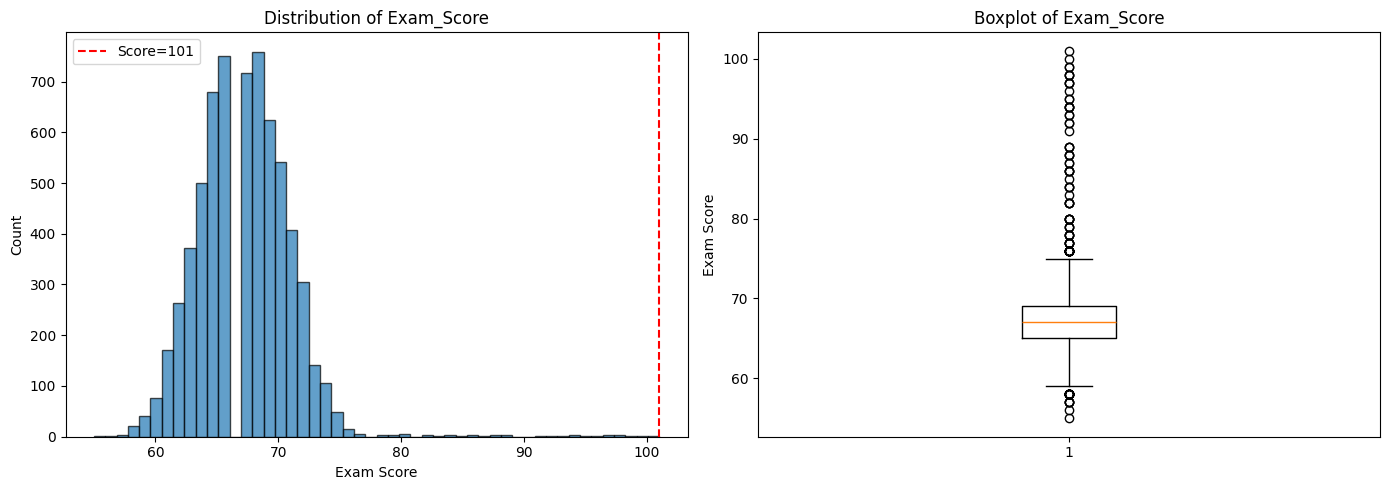

In [12]:
# Visualize phan bo Exam_Score de thay ro outlier
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df["Exam_Score"], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(x=101, color='red', linestyle='--', label='Score=101')
axes[0].set_title("Distribution of Exam_Score")
axes[0].set_xlabel("Exam Score")
axes[0].set_ylabel("Count")
axes[0].legend()

# Boxplot
axes[1].boxplot(df["Exam_Score"], vert=True)
axes[1].set_title("Boxplot of Exam_Score")
axes[1].set_ylabel("Exam Score")

plt.tight_layout()
plt.show()


### Ket luan Mission 4

**Quan sat:**  
Co dung 1 record (index 1525) co `Exam_Score = 101`, vuot qua 100. Min = 55, Max = 101. Ngoai ra, theo IQR method (Q1=65, Q3=69, upper fence=75), co 76 gia tri nam tren upper fence, nhung chung van nam trong khoang hop ly (76-100) cho thang diem thi.

**Quyet dinh de xuat:** **Cap gia tri 101 thanh 100** (trong buoc cleaning o Mission 5).

**Ly do:**  
- Record 1525 co cac feature hoan toan hop ly (Hours_Studied=27, Attendance=98, Previous_Scores=93, Tutoring_Sessions=5) — day la profile sinh vien hoc tot, nen diem cao la co co so.
- Gia tri 101 rat co the la loi nhap lieu (data entry error) — vi du go "101" thay vi "100" hoac do rounding error. Chi vuot 1 don vi so voi thang toi da.
- Khong nen xoa record nay vi toan bo thong tin feature van huu ich. Thay vao do, cap `Exam_Score = 101` thanh `100` la hop ly nhat.
- 75 record khac co Exam_Score > 75 (upper fence) nhung van nam trong thang diem 0-100, day la outlier thong ke nhung **khong phai loi** — chi la sinh vien dat diem cao. **Khong nen xoa hoac cap** cac gia tri nay.

> Nho: Outlier != Error.


# Mission 5 — Handle missing values

## Nhiệm vụ

Voi tung cot co missing values:

1. Xac dinh semantic type.
2. De xuat mot chien luoc xu ly.
3. Giai thich vi sao.
4. Tao `df_clean` tu `df.copy()` roi thuc hien lua chon cua ban.

Cac lua chon co the can nhac:

- loai bo record;
- dien mode;
- tao category `Unknown`;
- hoac giu missing de xu ly trong pipeline sau.

Khong co mot dap an mac dinh cho moi cot.


In [13]:
df_clean = df.copy()

# --- 1. Cap Exam_Score = 101 thanh 100 (tu Mission 4) ---
df_clean.loc[df_clean["Exam_Score"] > 100, "Exam_Score"] = 100
print("Exam_Score max after cap:", df_clean["Exam_Score"].max())

# --- 2. Xu ly missing values ---

# Teacher_Quality: 78 missing (1.18%) - ordinal categorical
# Chien luoc: Dien "Unknown" vi khong biet chat luong giao vien thuc te
# -> giu thong tin "thieu du lieu" thay vi gia dinh mot muc cu the
df_clean["Teacher_Quality"] = df_clean["Teacher_Quality"].fillna("Unknown")

# Parental_Education_Level: 90 missing (1.36%) - ordinal categorical
# Chien luoc: Dien "Unknown" vi trinh do phu huynh khong nen gia dinh
# -> mode la "High School" nhung dien mode se bias ket qua
df_clean["Parental_Education_Level"] = df_clean["Parental_Education_Level"].fillna("Unknown")

# Distance_from_Home: 67 missing (1.01%) - ordinal categorical
# Chien luoc: Dien "Unknown" vi khoang cach khong ro thi khong nen doan
df_clean["Distance_from_Home"] = df_clean["Distance_from_Home"].fillna("Unknown")

print("\nMissing values after processing:")
remaining = df_clean.isna().sum()
remaining = remaining[remaining > 0]
if len(remaining) == 0:
    print("-> Khong con missing values!")
else:
    display(remaining)


Exam_Score max after cap: 100

Missing values after processing:
-> Khong con missing values!


In [14]:
# Kiem tra lai value counts sau khi xu ly
for col in ["Teacher_Quality", "Parental_Education_Level", "Distance_from_Home"]:
    print(f"\n--- {col} ---")
    print(df_clean[col].value_counts())



--- Teacher_Quality ---
Teacher_Quality
Medium     3925
High       1947
Low         657
Unknown      78
Name: count, dtype: int64

--- Parental_Education_Level ---
Parental_Education_Level
High School     3223
College         1989
Postgraduate    1305
Unknown           90
Name: count, dtype: int64

--- Distance_from_Home ---
Distance_from_Home
Near        3884
Moderate    1998
Far          658
Unknown       67
Name: count, dtype: int64


### Giai thich chien luoc xu ly missing

| Cot | Chien luoc | Ly do |
|---|---|---|
| `Teacher_Quality` | Dien `"Unknown"` | Day la bien ordinal (Low/Medium/High). Dien mode (Medium, chiem 60%) se tao bias lon. Tao category "Unknown" giu duoc thong tin "khong ro" va de model tu hoc y nghia. |
| `Parental_Education_Level` | Dien `"Unknown"` | Bien ordinal (High School/College/Postgraduate). Khong co co so de gia dinh trinh do phu huynh khi thieu du lieu. Dien mode (High School) se bias ket qua ve nhom thap nhat. |
| `Distance_from_Home` | Dien `"Unknown"` | Bien ordinal (Near/Moderate/Far). Khoang cach thuc te khong ro thi khong nen doan. Ty le missing (1.01%) du nho de "Unknown" khong anh huong lon. |
| `Exam_Score` (101->100) | Cap gia tri | Chi 1 record, rat co the la loi nhap lieu (vuot thang 100). Giu record, cap score ve 100. |

**Nhan xet bo sung:**  
Chien luoc chung la tao category `"Unknown"` thay vi dien mode hoac xoa record vi: (1) ty le missing rat thap (~1%), (2) ca 3 cot deu la categorical — dien mode se tao bias khong can thiet, (3) giu nguyen record tranh mat thong tin o cac feature khac, (4) khi modeling, "Unknown" co the mang thong tin huu ich (vi du: sinh vien thieu thong tin phu huynh co the lien quan den hoan canh dac biet).


# Mission 6 — EDA driven by questions

Trong phan nay, **bieu do la cong cu de tra loi cau hoi**, khong phai muc tieu.

Moi bieu do phai di kem nhan xet ngan.


## Question 1 — `Exam_Score` phan bo nhu the nao?

Hay dung histogram.

Quan sat:

- diem tap trung o dau?
- phan bo co lech khong?
- co gia tri bat thuong khong?


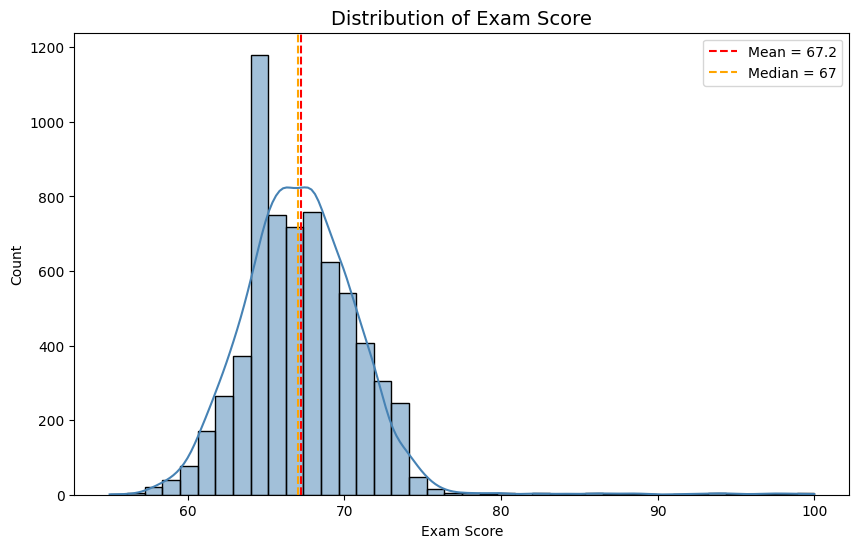

Skewness: 1.638
Kurtosis: 10.496


In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_clean, x="Exam_Score", kde=True, bins=40, color="steelblue")
plt.axvline(x=df_clean["Exam_Score"].mean(), color='red', linestyle='--',
            label=f'Mean = {df_clean["Exam_Score"].mean():.1f}')
plt.axvline(x=df_clean["Exam_Score"].median(), color='orange', linestyle='--',
            label=f'Median = {df_clean["Exam_Score"].median():.0f}')
plt.title("Distribution of Exam Score", fontsize=14)
plt.xlabel("Exam Score")
plt.ylabel("Count")
plt.legend()
plt.show()

# Thong ke bo sung
print(f"Skewness: {df_clean['Exam_Score'].skew():.3f}")
print(f"Kurtosis: {df_clean['Exam_Score'].kurtosis():.3f}")


**Nhan xet Q1:**  
Phan bo `Exam_Score` tap trung chu yeu trong khoang **63-71 diem**, voi mean ~ 67.2 va median = 67 — gan nhau cho thay phan bo tuong doi doi xung quanh gia tri trung tam. Tuy nhien, phan bo co duoi phai dai hon (right-skewed nhe), voi mot so it sinh vien dat diem rat cao (80-100). Duong KDE cho thay dinh ro rang quanh 67 diem. Phan lon sinh vien (50%) dat tu 65 den 69 diem (khoang IQR), cho thay su khac biet diem so giua da so sinh vien khong qua lon.


## Question 2 — Hoc nhieu hon co dong nghia diem cao hon?

Ve `Hours_Studied` vs `Exam_Score`.


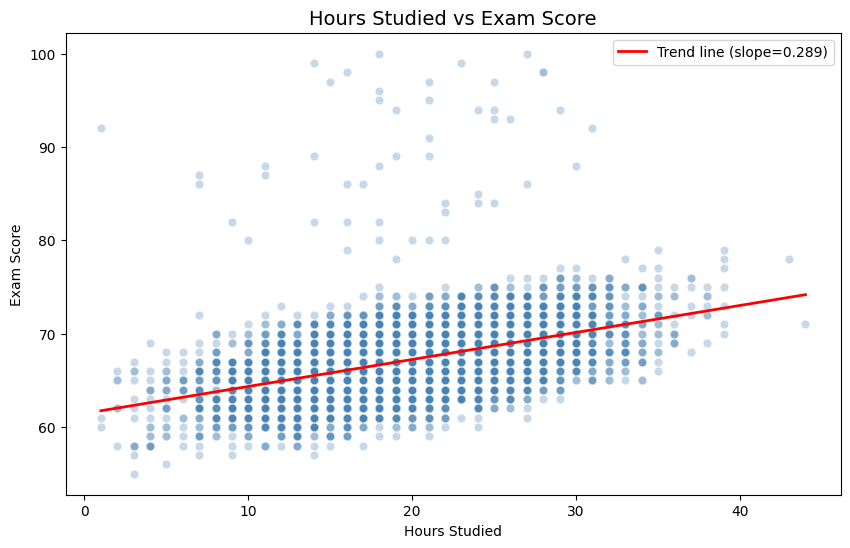

Pearson correlation: 0.4456


In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x="Hours_Studied", y="Exam_Score", alpha=0.3, color="steelblue")

# Them duong xu huong (regression line)
z = np.polyfit(df_clean["Hours_Studied"], df_clean["Exam_Score"], 1)
p = np.poly1d(z)
x_line = np.linspace(df_clean["Hours_Studied"].min(), df_clean["Hours_Studied"].max(), 100)
plt.plot(x_line, p(x_line), color='red', linewidth=2, label=f'Trend line (slope={z[0]:.3f})')

plt.title("Hours Studied vs Exam Score", fontsize=14)
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.legend()
plt.show()

# He so tuong quan
corr = df_clean["Hours_Studied"].corr(df_clean["Exam_Score"])
print(f"Pearson correlation: {corr:.4f}")


**Nhan xet Q2:**  
Scatter plot cho thay xu huong tich cuc (positive trend): sinh vien hoc nhieu gio hon **co xu huong** dat diem cao hon. He so tuong quan Pearson ~ 0.445 cho thay moi quan he tuyen tinh duong o muc trung binh. Duong trend line co slope duong, xac nhan xu huong nay. Tuy nhien, do phan tan (scatter) van kha rong — o moi muc gio hoc, diem thi van dao dong dang ke. Dieu nay cho thay `Hours_Studied` la feature huu ich nhung khong phai yeu to duy nhat quyet dinh `Exam_Score`.

> Luu y: tuong quan khong dong nghia nhan qua.


## Question 3 — `Attendance` hay `Hours_Studied` trong huu ich hon?

Ve `Attendance` vs `Exam_Score`, sau do so sanh voi bieu do truoc.


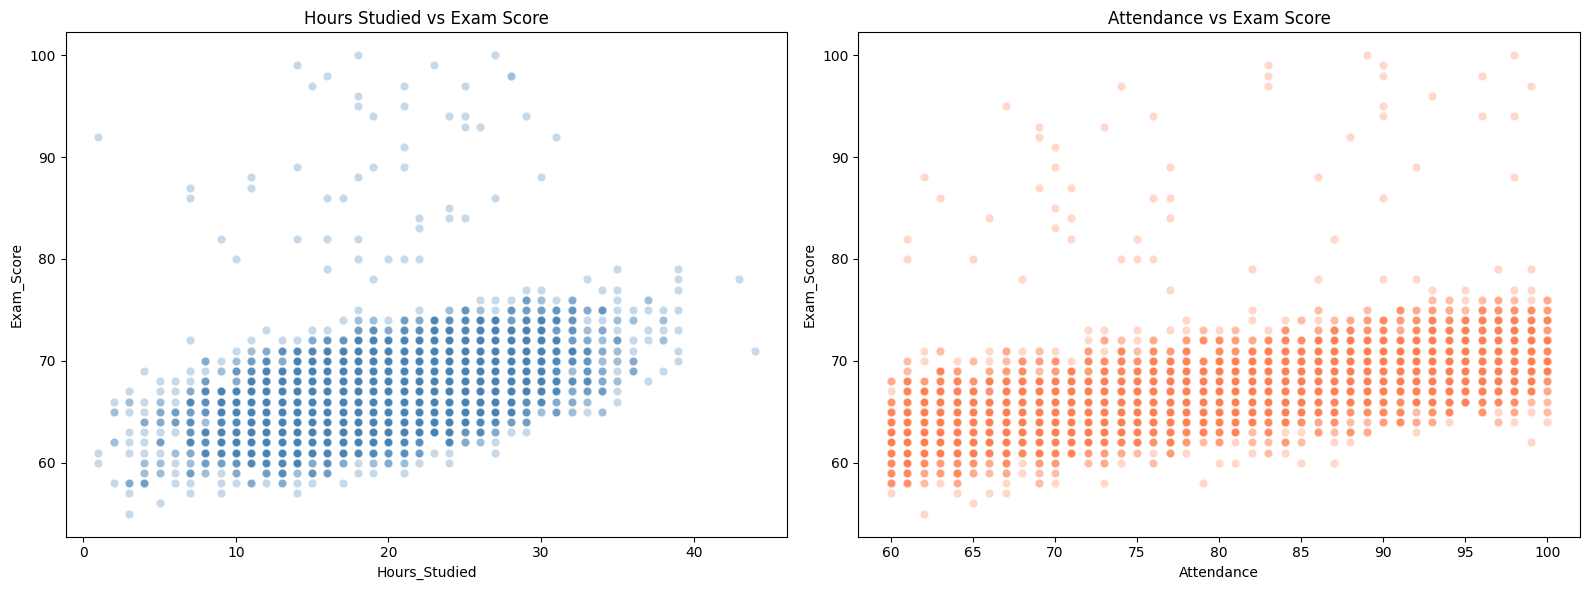

,Hours_Studied,Attendance,Previous_Scores,Exam_Score
Hours_Studied,1.000000,-0.009908,0.024846,0.445558
Attendance,-0.009908,1.000000,-0.020186,0.581205
Previous_Scores,0.024846,-0.020186,1.000000,0.175089
Exam_Score,0.445558,0.581205,0.175089,1.000000


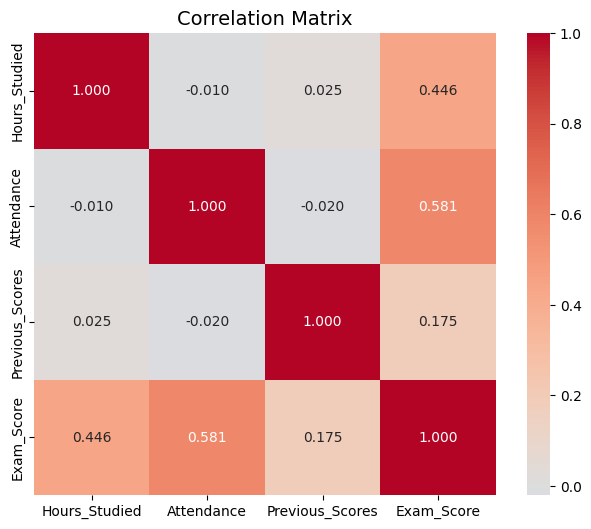

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Hours_Studied vs Exam_Score
sns.scatterplot(data=df_clean, x="Hours_Studied", y="Exam_Score", alpha=0.3, ax=axes[0], color="steelblue")
axes[0].set_title("Hours Studied vs Exam Score", fontsize=12)

# Attendance vs Exam_Score
sns.scatterplot(data=df_clean, x="Attendance", y="Exam_Score", alpha=0.3, ax=axes[1], color="coral")
axes[1].set_title("Attendance vs Exam Score", fontsize=12)

plt.tight_layout()
plt.show()

# Ma tran tuong quan
corr_cols = ["Hours_Studied", "Attendance", "Previous_Scores", "Exam_Score"]
corr_matrix = df_clean[corr_cols].corr()
display(corr_matrix)

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".3f", square=True)
plt.title("Correlation Matrix", fontsize=14)
plt.show()


**Nhan xet Q3:**  
So sanh hai scatter plot va ma tran tuong quan cho thay `Attendance` co tuong quan manh hon voi `Exam_Score` (r ~ **0.581**) so voi `Hours_Studied` (r ~ **0.445**). Dieu nay goi y rang **viec di hoc deu dan** co lien he chat che hon voi diem thi so voi so gio tu hoc. Scatter plot cua `Attendance` cung cho thay xu huong tuyen tinh ro rang hon, voi diem phan tan it hon. `Previous_Scores` cung co tuong quan duong voi `Exam_Score` (r ~ 0.175) nhung yeu hon hai bien kia. Dang chu y, `Hours_Studied` va `Attendance` gan nhu khong tuong quan voi nhau (r ~ -0.01), nghia la chung cung cap thong tin bo sung (complementary) cho nhau — ca hai deu nen duoc giu lai lam features.


## Question 4 — Cac muc `Motivation_Level` co phan bo `Exam_Score` giong nhau khong?

Chon bieu do phu hop cho bien categorical/ordinal.


C:\Users\NGHIEM PHUC\AppData\Local\Temp\ipykernel_17536\3328972022.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="Motivation_Level", y="Exam_Score", order=order,
C:\Users\NGHIEM PHUC\AppData\Local\Temp\ipykernel_17536\3328972022.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x="Motivation_Level", y="Exam_Score", order=order,


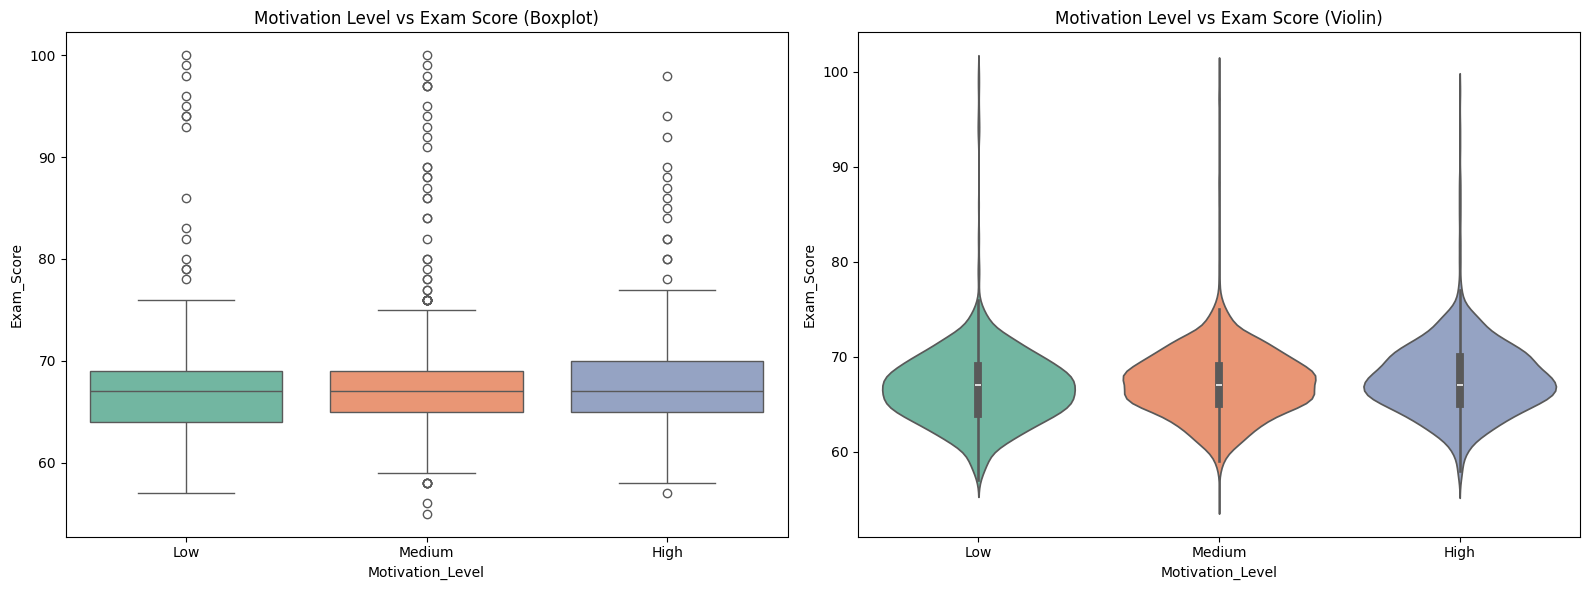

Thong ke Exam_Score theo Motivation_Level:


,count,mean,std,min,25%,50%,75%,max
Motivation_Level,,,,,,,,
Low,1937.0,66.751678,3.953733,57.0,64.0,67.0,69.0,100.0
Medium,3351.0,67.330648,3.827303,55.0,65.0,67.0,69.0,100.0
High,1319.0,67.704321,3.876966,57.0,65.0,67.0,70.0,98.0


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
order = ["Low", "Medium", "High"]
sns.boxplot(data=df_clean, x="Motivation_Level", y="Exam_Score", order=order,
            palette="Set2", ax=axes[0])
axes[0].set_title("Motivation Level vs Exam Score (Boxplot)", fontsize=12)

# Violin plot cho thay ro phan bo hon
sns.violinplot(data=df_clean, x="Motivation_Level", y="Exam_Score", order=order,
               palette="Set2", ax=axes[1])
axes[1].set_title("Motivation Level vs Exam Score (Violin)", fontsize=12)

plt.tight_layout()
plt.show()

# Thong ke theo nhom
print("Thong ke Exam_Score theo Motivation_Level:")
display(df_clean.groupby("Motivation_Level")["Exam_Score"].describe().loc[order])


**Nhan xet Q4:**  
Ba muc `Motivation_Level` co phan bo `Exam_Score` **kha tuong tu nhau**. Mean cua nhom High (~67.7) chi cao hon nhom Low (~66.8) khoang 1 diem — su khac biet rat nho so voi std ~ 3.9. Boxplot va violin plot cho thay median, IQR, va hinh dang phan bo gan nhu giong nhau giua 3 nhom. Dieu nay goi y rang `Motivation_Level` **don le** co the khong phai la feature manh de du doan `Exam_Score`, hoac anh huong cua no chi ro rang khi ket hop voi cac yeu to khac (interaction effects).

**Co the ket luan quan he nhan qua khong? Vi sao?**  
**Khong the.** Day la du lieu quan sat (observational data), khong phai thi nghiem co kiem soat (controlled experiment). Su khac biet nho giua cac nhom co the do nhieu yeu to gay nhieu (confounders). Vi du: sinh vien co `Motivation_Level = High` co the cung co `Hours_Studied` cao hon, `Attendance` tot hon — ta khong the tach rieng anh huong thuan cua motivation. Ngoai ra, bien `Motivation_Level` la tu bao cao (self-reported), co the khong phan anh chinh xac dong luc thuc te.


# Final — Data Readiness Report

Hoan thien bao cao nhu mot thanh vien cua **DNU Learning Analytics Lab**.

## 1. Bai toan

Chung toi muon du doan: **Diem thi cuoi ky (`Exam_Score`) cua sinh vien dua tren cac yeu to lien quan den hoc tap, gia dinh, va moi truong giao duc.**

## 2. Target

`Exam_Score` — bien so nguyen (int), pham vi 55-100 (sau khi cap), bai toan **regression**.

## 3. Features du kien

19 features chia thanh:
- **Numerical (6):** `Hours_Studied`, `Attendance`, `Sleep_Hours`, `Previous_Scores`, `Tutoring_Sessions`, `Physical_Activity`
- **Binary categorical (3):** `Extracurricular_Activities`, `Internet_Access`, `Learning_Disabilities`
- **Nominal categorical (2):** `School_Type`, `Gender`
- **Ordinal categorical (8):** `Parental_Involvement`, `Access_to_Resources`, `Motivation_Level`, `Family_Income`, `Teacher_Quality`, `Peer_Influence`, `Parental_Education_Level`, `Distance_from_Home`

## 4. Van de du lieu da phat hien

1. **Missing values** o 3 cot categorical: `Parental_Education_Level` (90, 1.36%), `Teacher_Quality` (78, 1.18%), `Distance_from_Home` (67, 1.01%). Ty le thap.
2. **Gia tri bat thuong:** 1 record co `Exam_Score = 101` vuot thang 100 diem — rat co the la loi nhap lieu.
3. **Dtype chua phan anh ngu nghia:** Cac cot ordinal categorical dang luu dang `object`, chua encode thu tu.
4. **Khong co** duplicate, khong co category typo, khong co gia tri am bat hop ly.

## 5. Cach xu ly da chon

- **Missing values:** Dien `"Unknown"` cho ca 3 cot (`Teacher_Quality`, `Parental_Education_Level`, `Distance_from_Home`). Ly do: ty le thap, la bien categorical, dien mode se tao bias, giu thong tin "khong ro" co the huu ich cho model.
- **Exam_Score = 101:** Cap thanh 100. Ly do: rat co the loi nhap lieu, giu record vi features van huu ich.
- **Chua xu ly:** Encoding ordinal/nominal categorical (de lai cho buoc preprocessing trong pipeline).

## 6. Ba pattern dang chu y tu EDA

1. **`Attendance` la feature co tuong quan manh nhat** voi `Exam_Score` (r ~ 0.581), manh hon ca `Hours_Studied` (r ~ 0.445). Di hoc deu dan co lien he chat voi diem cao hon la tu hoc nhieu gio.
2. **`Hours_Studied` va `Attendance` gan nhu khong tuong quan voi nhau** (r ~ -0.01), cung cap thong tin bo sung (complementary). Ca hai nen duoc giu lam features.
3. **`Motivation_Level` hau nhu khong tao khac biet** dang ke ve `Exam_Score` (chenh lech mean giua High va Low chi ~1 diem). Feature nay co the co anh huong yeu hoac chi co y nghia khi ket hop voi features khac.

## 7. Dataset da san sang cho modeling chua?

**Not yet** — can them mot so buoc preprocessing.

**Giai thich:**  
Dataset da qua buoc lam sach co ban (xu ly missing, cap gia tri bat thuong) va co chat luong tot. Tuy nhien, de dua vao model machine learning, can them cac buoc: (1) **Encode ordinal categorical** theo dung thu tu (vi du: Low=0, Medium=1, High=2), (2) **Encode nominal/binary categorical** bang One-Hot Encoding hoac Label Encoding, (3) **Feature scaling** cho cac bien numerical neu dung model nhay voi scale (SVM, KNN, Linear Regression). Dataset cung nen duoc chia thanh train/test set truoc khi fit model. Ngoai ra, co the can kiem tra multicollinearity giua cac features va can nhac feature engineering.

---

## Cau hoi ket thuc

Neu buoc tiep theo la huan luyen mot mo hinh tu cac feature hien co, con van de preprocessing nao chung ta chua giai quyet?

1. **Encoding categorical features:** Cac cot ordinal can Ordinal Encoding (giu thu tu), cac cot nominal/binary can One-Hot Encoding hoac Label Encoding. Hien tai tat ca van dang string.
2. **Feature scaling:** Cac bien numerical co range rat khac nhau (`Attendance`: 60-100, `Hours_Studied`: 1-44, `Physical_Activity`: 0-6). Cac model dua tren khoang cach (KNN, SVM) hoac gradient (Logistic Regression, Neural Network) can scaling.
3. **Train/Test split:** Chua chia du lieu. Can chia truoc khi fit de danh gia khach quan.
4. **Category `Unknown`:** Can quyet dinh xu ly category moi nay trong encoding pipeline (giu rieng hay gop).
5. **Feature selection / engineering:** Co the tao features moi (vi du: tong Hours_Studied x Attendance) hoac loai bo features yeu de giam noise.
